In [1]:
import shap
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import time

def SHAP_plt(keras,npy):

	shap.initjs()
    

# Load the Keras model
	keras_model = load_model(keras)

# Load the X_test data from the .npy file
	X_test = np.load(npy)[0:5]

	backgorund = np.transpose(np.genfromtxt('Backgr_1.dat'))[0:5,0:15000]
	start_time = time.time()

# Create SHAP explainer
	explainer = shap.Explainer(keras_model, masker = backgorund)

# Calculate SHAP values for the selected row
	shap_values = explainer.shap_values(X_test)

	end_time = time.time()
	S = keras.split(".")[0] + ".png"
# Create SHAP summary plot
	shap.summary_plot(shap_values, X_test, plot_type='violin',show = False)
	plt.savefig(S)
	plt.show()
	plt.close()

# Find the feature with the maximum absolute SHAP value
	max_feature_index = np.argmax(np.abs(shap_values.mean(0)))
	max_feature_value = X_test[:, max_feature_index].mean()
	max_feature_name = f"Feature {max_feature_index}"  # Adjust if your features start from 1

	print(f"Top Feature: {max_feature_name}")
	print(f"Top Feature Value: {max_feature_value}")

	dic_matrix = {

"Top Feature" : max_feature_name ,
   "Top Feature Value" :  max_feature_value ,
    "Time for Top Feature" : int(max_feature_name.split()[1]) / 250 ,
    "SHAP Time" : end_time - start_time ,
	"Name" : keras.split(".")[0] 
    
}
	return dic_matrix


2023-12-13 07:16:13.196611: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-13 07:16:14.185156: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Files with .keras extension:
- adamax_gamma_Necker cube.keras
- adamax_theta_Mona Lisa.keras
- adamax_theta_Necker cube.keras
- adamax_gamma_Mona Lisa.keras
- adamax_delta_Mona Lisa.keras
- adamax_delta_Necker cube.keras
- adamax_beta_Necker cube.keras
- adamax_beta_Mona Lisa.keras
- adamax_alpha_Mona Lisa.keras
- adamax_alpha_Necker cube.keras

Files with .npy extension:
- adamax_alpha_Necker cube.npy
- adamax_beta_Necker cube.npy
- adamax_beta_Mona Lisa.npy
- adamax_gamma_Necker cube.npy
- adamax_gamma_Mona Lisa.npy
- adamax_theta_Necker cube.npy
- adamax_delta_Necker cube.npy
- adamax_theta_Mona Lisa.npy
- adamax_delta_Mona Lisa.npy
- adamax_alpha_Mona Lisa.npy

Checking for corresponding pairs:
adamax_gamma_Necker cube.keras has a corresponding adamax_gamma_Necker cube.npy 


2023-12-13 07:16:15.011439: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
PermutationExplainer explainer: 6it [19:01, 228.37s/it]                


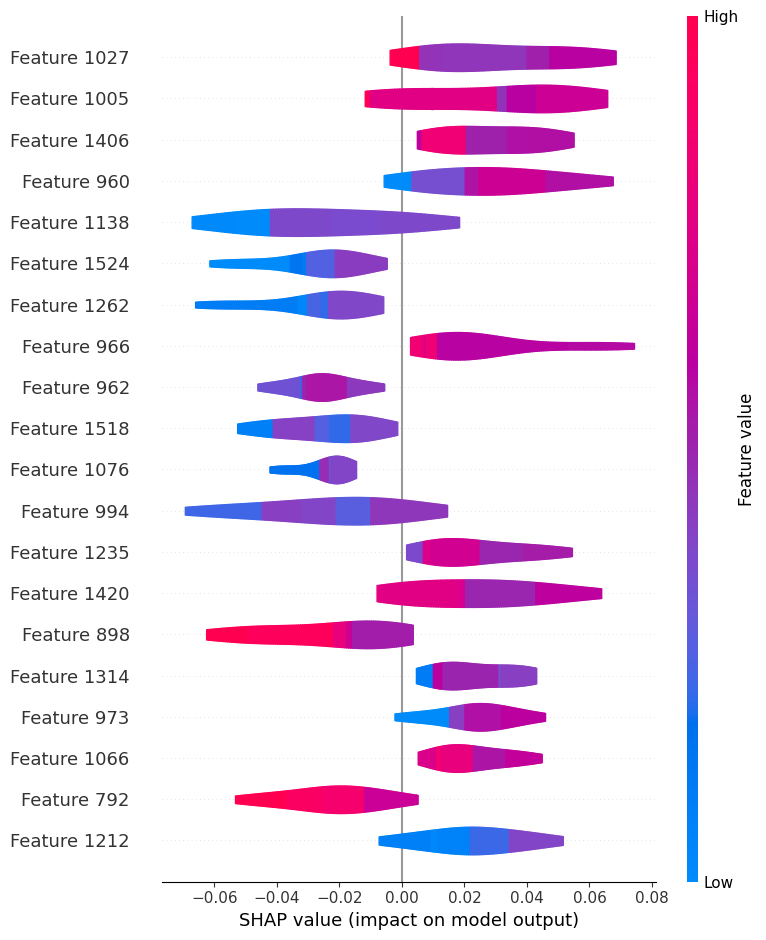

Top Feature: Feature 1027
Top Feature Value: -2.735252274228577
adamax_theta_Mona Lisa.keras has a corresponding adamax_theta_Mona Lisa.npy 


PermutationExplainer explainer: 6it [18:28, 221.73s/it]                


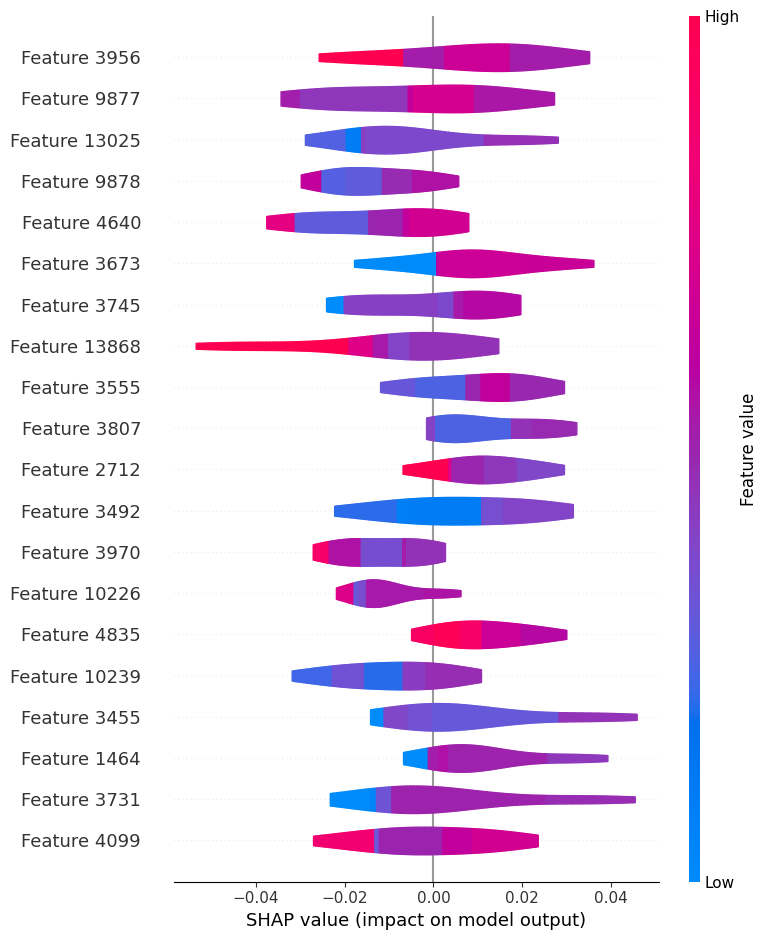

Top Feature: Feature 9878
Top Feature Value: 4.324592238317277
adamax_theta_Necker cube.keras has a corresponding adamax_theta_Necker cube.npy 


PermutationExplainer explainer: 6it [18:29, 221.87s/it]                


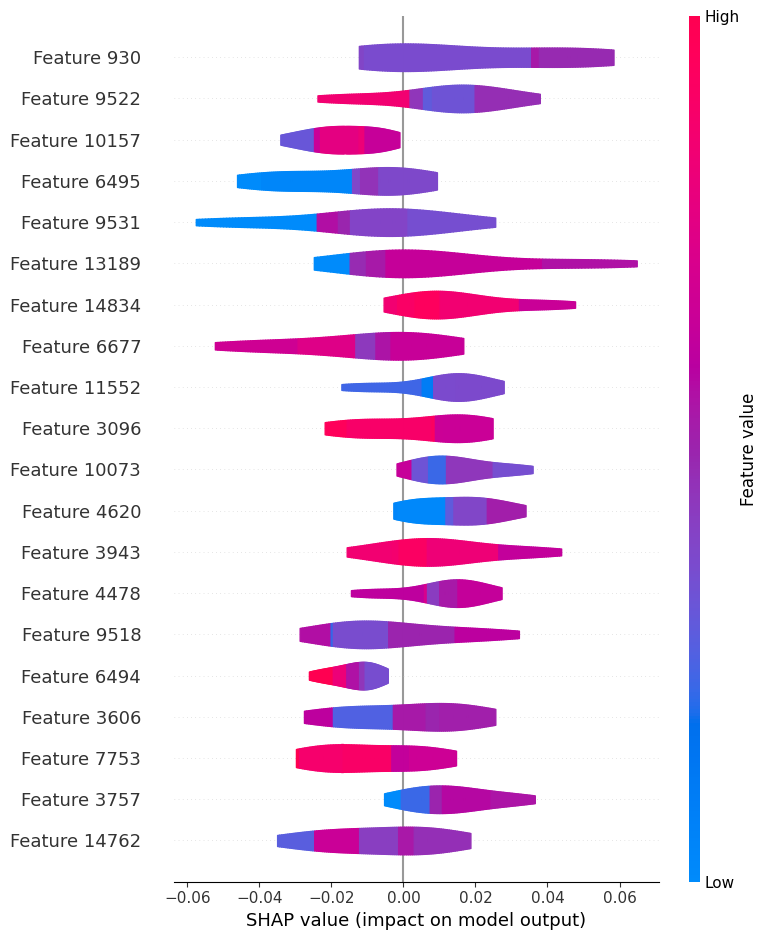

Top Feature: Feature 930
Top Feature Value: -3.242496965014831
adamax_gamma_Mona Lisa.keras has a corresponding adamax_gamma_Mona Lisa.npy 


PermutationExplainer explainer: 6it [18:33, 222.78s/it]                


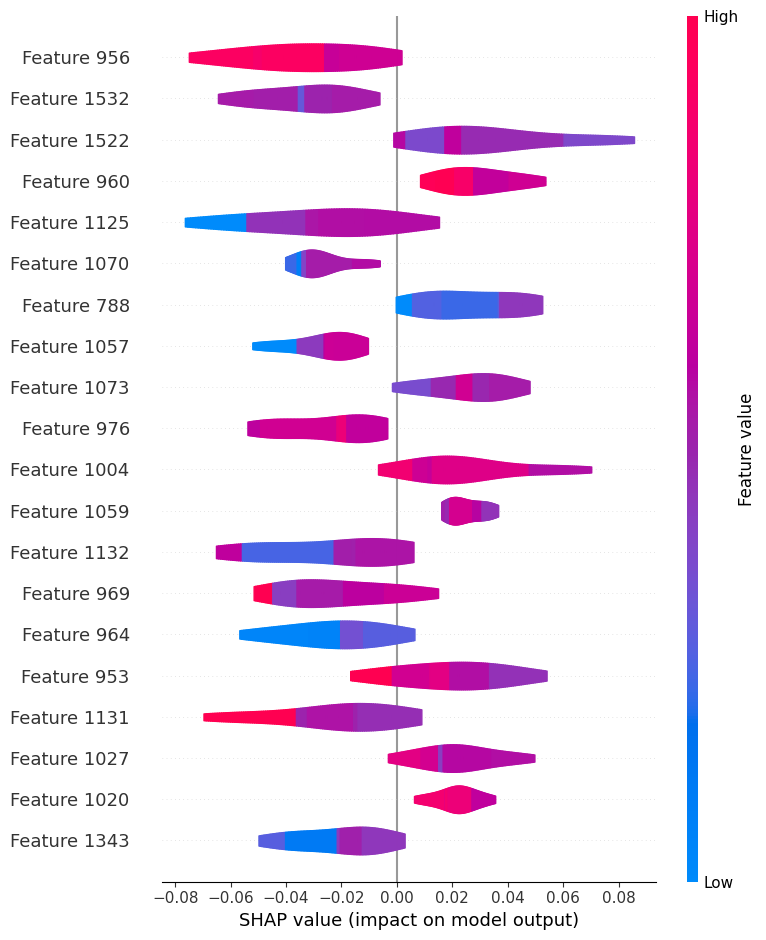

Top Feature: Feature 956
Top Feature Value: -2.5558748821162722
adamax_delta_Mona Lisa.keras has a corresponding adamax_delta_Mona Lisa.npy 


PermutationExplainer explainer: 6it [18:32, 222.42s/it]                


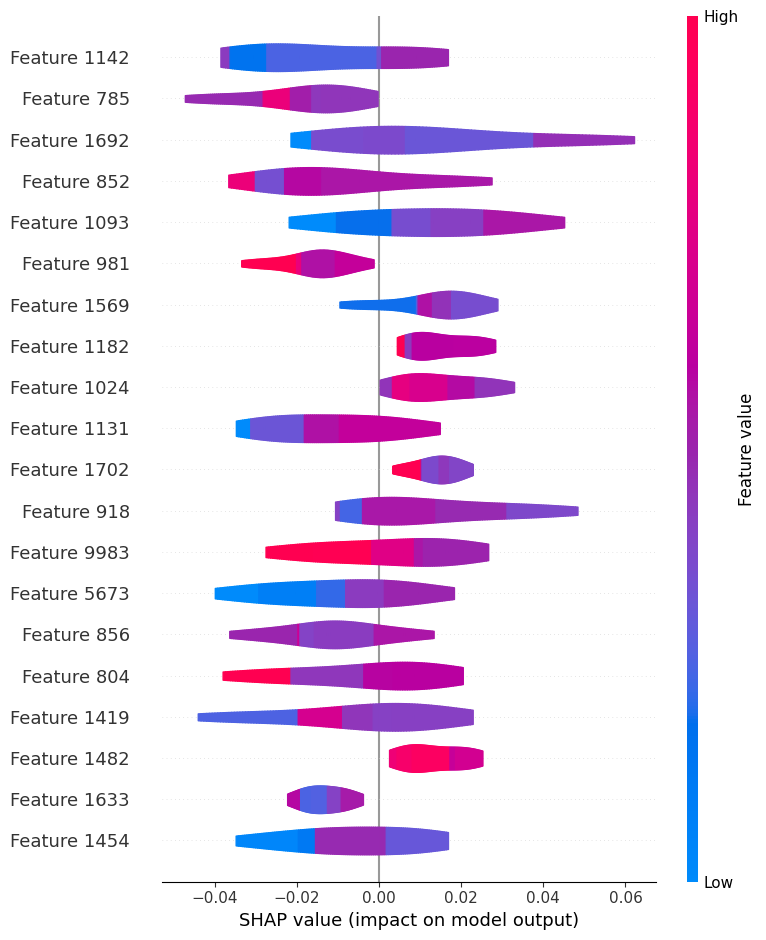

Top Feature: Feature 785
Top Feature Value: -2.4603282475806765
adamax_delta_Necker cube.keras has a corresponding adamax_delta_Necker cube.npy 


PermutationExplainer explainer: 6it [18:30, 222.14s/it]                


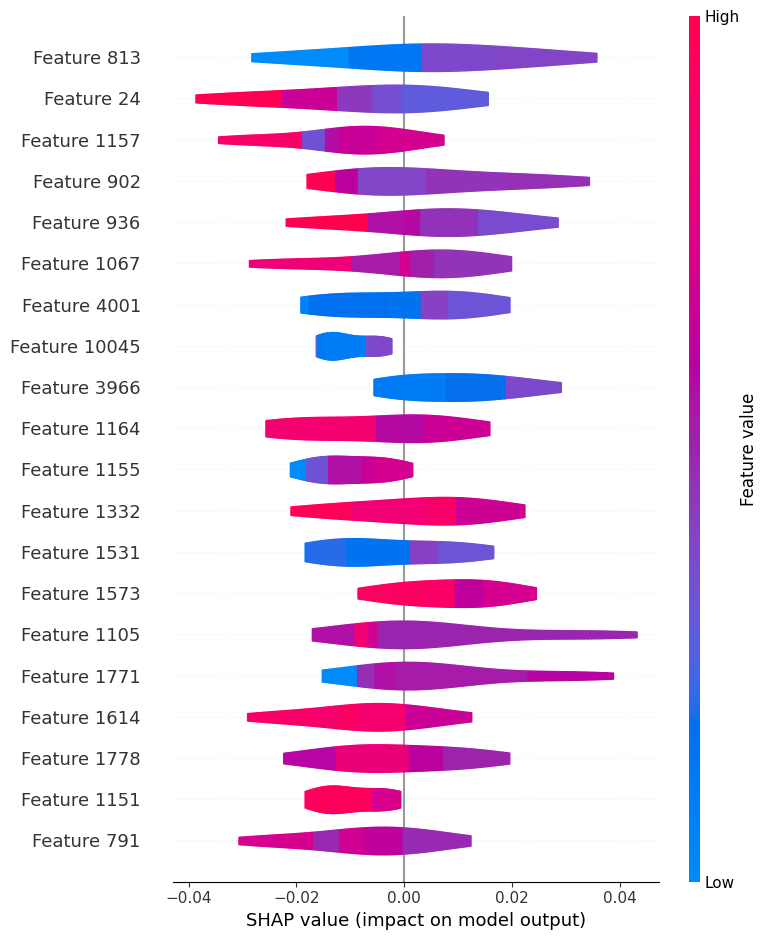

Top Feature: Feature 1157
Top Feature Value: -140.27044330096868
adamax_beta_Necker cube.keras has a corresponding adamax_beta_Necker cube.npy 


PermutationExplainer explainer: 6it [18:29, 221.98s/it]                


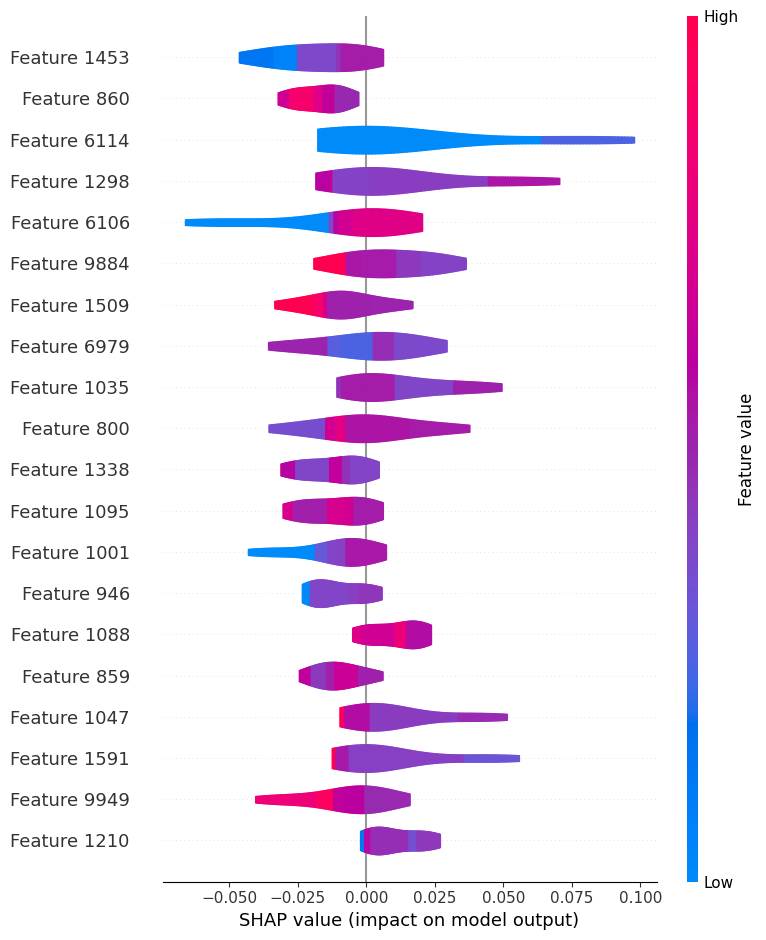

Top Feature: Feature 1453
Top Feature Value: -10.04354663705539
adamax_beta_Mona Lisa.keras has a corresponding adamax_beta_Mona Lisa.npy 


PermutationExplainer explainer: 6it [18:31, 222.27s/it]                


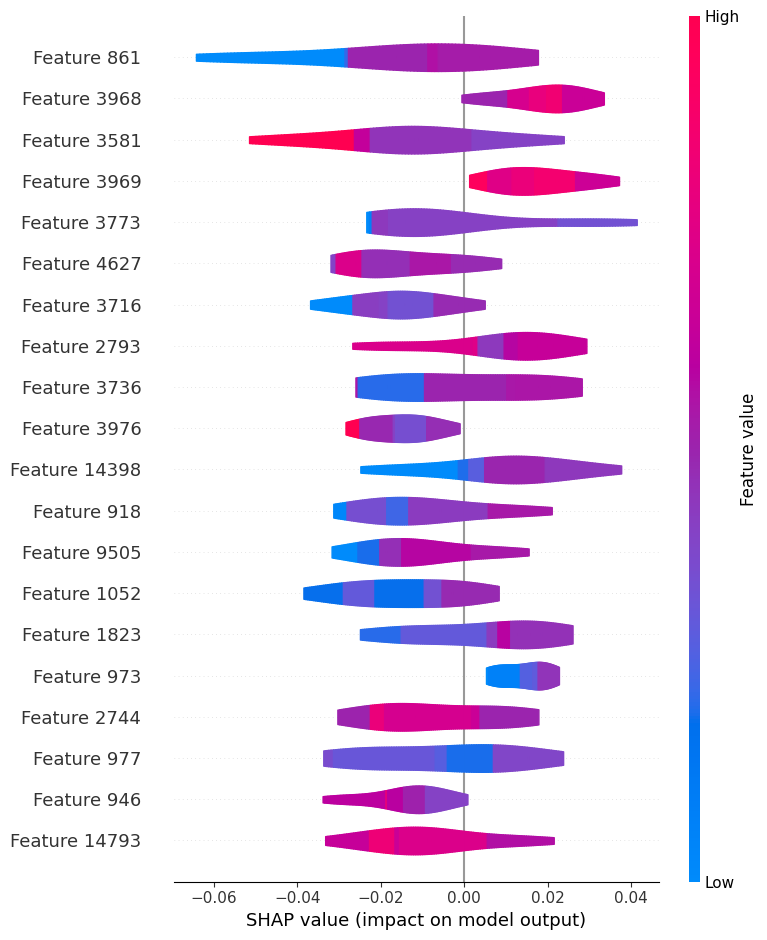

Top Feature: Feature 3968
Top Feature Value: -37.14838034930911
adamax_alpha_Mona Lisa.keras has a corresponding adamax_alpha_Mona Lisa.npy 


PermutationExplainer explainer: 6it [18:33, 222.77s/it]                


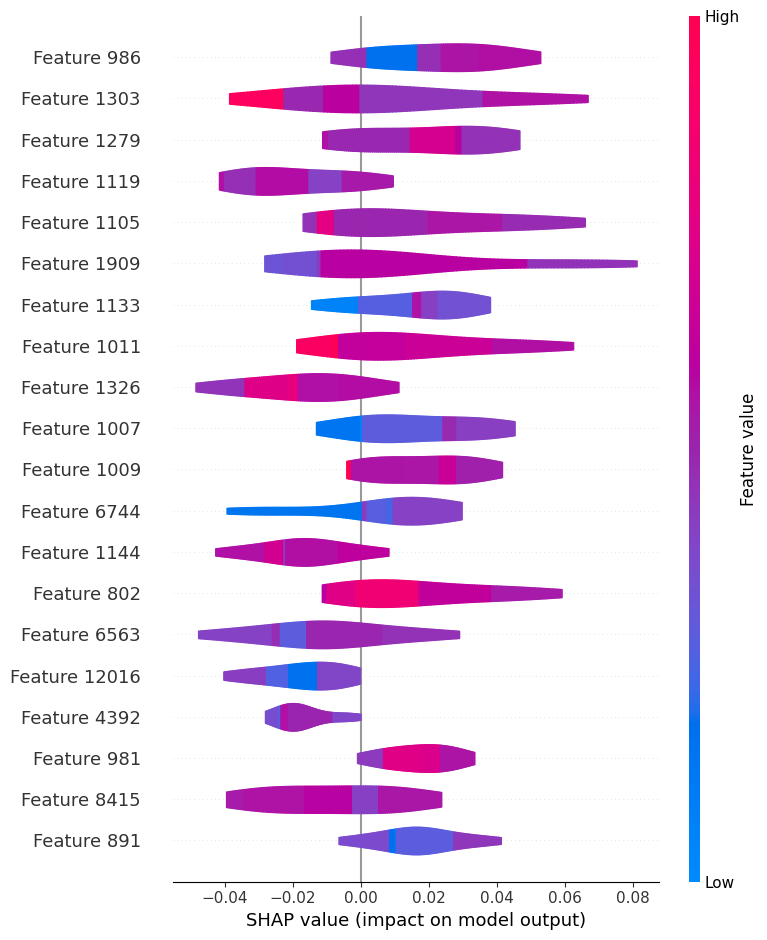

Top Feature: Feature 986
Top Feature Value: -12.89745085149516
adamax_alpha_Necker cube.keras has a corresponding adamax_alpha_Necker cube.npy 


PermutationExplainer explainer: 6it [18:25, 221.19s/it]                


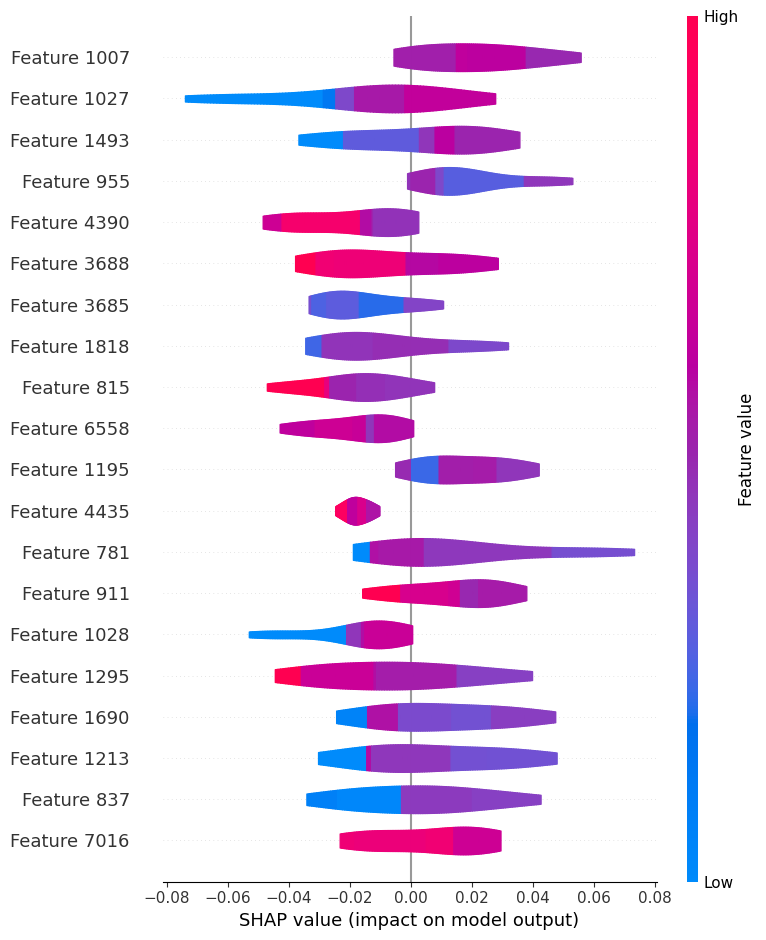

Top Feature: Feature 1007
Top Feature Value: 4.586674130949402


In [2]:
import os
import pandas as pd

# Get the current directory
current_directory = os.getcwd()

# List all files with .keras and .npy extensions
keras_files = [file for file in os.listdir(current_directory) if file.endswith('.keras')]
npy_files = [file for file in os.listdir(current_directory) if file.endswith('.npy')]

# Print the to-do list
print("Files with .keras extension:")
for keras_file in keras_files:
	print(f"- {keras_file}")

print("\nFiles with .npy extension:")
for npy_file in npy_files:
	print(f"- {npy_file}")

shap_result = pd.DataFrame()
# Check for corresponding pairs
print("\nChecking for corresponding pairs:")
for keras_file in keras_files:
    npy_file = keras_file.replace('.keras', '.npy')
    if npy_file in npy_files:
        print(f"{keras_file} has a corresponding {npy_file} ")
        matrix = SHAP_plt(keras_file,npy_file)
        matrix_df = pd.DataFrame([matrix])
        shap_result = pd.concat([shap_result, matrix_df], ignore_index= True)
        shap_result.to_csv("output.csv")
    else:
    	print(f"No corresponding .npy file found for {keras_file}")